In [6]:
import pandas as pd
import numpy as np

# ============================================
# 1. LOAD THE DATASET
# (na_values tells pandas which strings mean "missing" while reading the file)
# ============================================
missing_markers = ["?", "NA", "N/A", "n/a", "na", "--", "-", "null", "NULL", "None"]

df = pd.read_csv("Automobile_data.csv", na_values=missing_markers)

# ============================================
# 2. BASIC SHAPE
# ============================================
print("SHAPE (rows, columns):", df.shape)

# ============================================
# 3. COLUMN NAMES
# ============================================
print("\nColumn names:")
print(df.columns.tolist())

# ============================================
# 4. DATA TYPES (before fixing)
# ============================================
print("\nData types (before fixing numeric columns):")
print(df.dtypes)

# ============================================
# 5. FIRST FEW ROWS
# ============================================
print("\nFirst 5 rows:")
print(df.head())

# ============================================
# 6. ACTUAL MISSING VALUES (the real numbers)
# ============================================
print("\nMissing values PER COLUMN (count):")
print(df.isnull().sum())

print("\nMissing values PER COLUMN (percentage):")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nTOTAL missing values in entire dataset:", df.isnull().sum().sum())

print("\nRows that contain AT LEAST ONE missing value:", df.isnull().any(axis=1).sum())

print("\nRows with NO missing values at all:", df.dropna().shape[0])

# ============================================
# 7. FIX NUMERIC COLUMNS
# (these are numeric but loaded as 'object' due to missing markers)
# ============================================
numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower',
                 'peak-rpm', 'price']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nData types after fixing numeric columns:")
print(df.dtypes)

# ============================================
# 8. SUMMARY STATISTICS
# ============================================

print("\nSummary stats (all columns, including categorical):")
print(df.describe(include='all'))

# ============================================
# 9. DUPLICATE ROWS
# ============================================
print("\nDuplicate rows:", df.duplicated().sum())

SHAPE (rows, columns): (205, 26)

Column names:
['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

Data types (before fixing numeric columns):
symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float

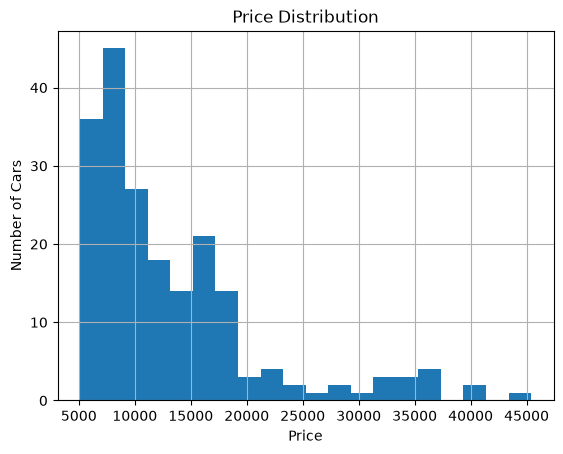

In [7]:
import matplotlib.pyplot as plt

df['price'].hist(bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

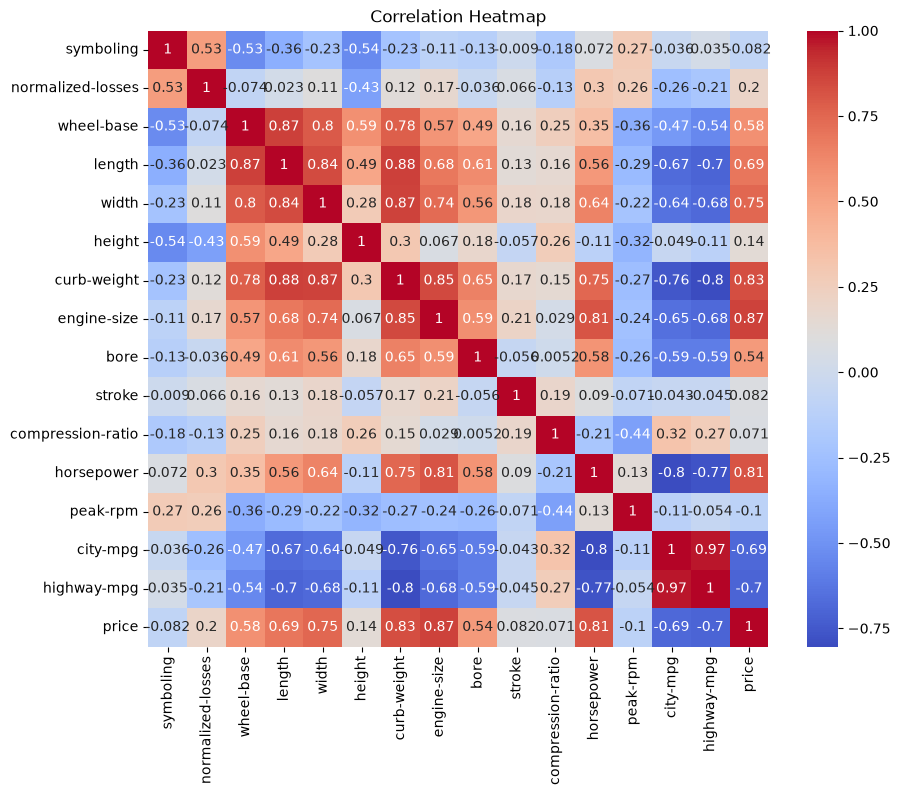

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()